In [2]:
import os, random, math
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from tqdm import tqdm

import torch
import torch.nn as nn
import torchvision
from torchsummary import summary
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset

from qiskit import QuantumCircuit
from qiskit.circuit import Parameter
from qiskit.circuit.library import RealAmplitudes, ZZFeatureMap
from qiskit_machine_learning.utils import algorithm_globals
from qiskit_machine_learning.neural_networks import SamplerQNN, EstimatorQNN
from qiskit_machine_learning.connectors import TorchConnector

import kagglehub
from PIL import Image

import pylatexenc

from sklearn.model_selection import train_test_split

c:\Users\maxsl\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
#max_in_class = 200
#train_part = 0.5
#noise = 0.1
batch_size = 1200

epochs = 20
initial_lr = 0.005

device = "cpu"

Path to dataset files: C:\Users\maxsl\.cache\kagglehub\datasets\paramaggarwal\fashion-product-images-small\versions\1
      id gender masterCategory subCategory  articleType baseColour  season  \
0  15970    Men        Apparel     Topwear       Shirts  Navy Blue    Fall   
1  39386    Men        Apparel  Bottomwear        Jeans       Blue  Summer   
2  59263  Women    Accessories     Watches      Watches     Silver  Winter   
3  21379    Men        Apparel  Bottomwear  Track Pants      Black    Fall   
4  53759    Men        Apparel     Topwear      Tshirts       Grey  Summer   

     year   usage                             productDisplayName  
0  2011.0  Casual               Turtle Check Men Navy Blue Shirt  
1  2012.0  Casual             Peter England Men Party Blue Jeans  
2  2016.0  Casual                       Titan Women Silver Watch  
3  2011.0  Casual  Manchester United Men Solid Black Track Pants  
4  2012.0  Casual                          Puma Men Grey T-shirt  


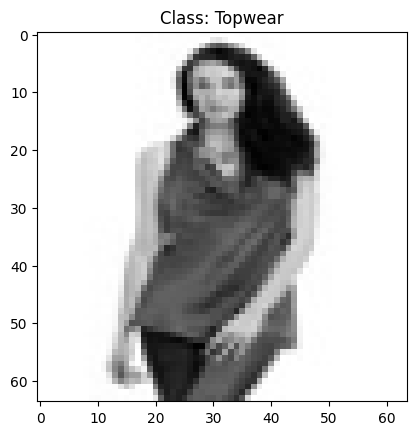

In [4]:
# 1. Скачиваем датасет
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-small")
print("Path to dataset files:", path)

# 2. Загружаем метаданные
meta = pd.read_csv(os.path.join(path, "styles.csv"), on_bad_lines='skip')
print(meta.head())

# 3. Оставляем только строки с нужными полями и существующими файлами
meta = meta.dropna(subset=['subCategory', 'id'])
meta['image_path'] = meta['id'].astype(str) + ".jpg"
meta = meta[meta['image_path'].apply(lambda x: os.path.isfile(os.path.join(path, "images", x)))]

# 4. Выбираем 10 самых популярных subCategory
top10 = meta['subCategory'].value_counts().index[:10]
meta = meta[meta['subCategory'].isin(top10)]
label2idx = {name: idx for idx, name in enumerate(top10)}
meta['label'] = meta['subCategory'].map(label2idx)

# 5. Класс Dataset
class FashionProductDataset(Dataset):
    def __init__(self, meta, img_dir, transform=None):
        self.meta = meta.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.meta)

    def __getitem__(self, idx):
        img_name = os.path.join(self.img_dir, "images", self.meta.loc[idx, "image_path"])
        image = Image.open(img_name).convert("L").resize((64,64))
        label = int(self.meta.loc[idx, "label"])
        if self.transform:
            image = self.transform(image)
        else:
            image = torchvision.transforms.ToTensor()(image)
        return image, label

# 6. Делим на train/test
train_meta, test_meta = train_test_split(meta, test_size=0.2, stratify=meta['label'], random_state=42)

train_dataset = FashionProductDataset(train_meta, path)
test_dataset = FashionProductDataset(test_meta, path)

train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=1, shuffle=True)

# 7. Для отображения названий классов
class_names = {idx: name for name, idx in label2idx.items()}
img, label = train_dataset[20]
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Class: {class_names[label]}")
plt.show()

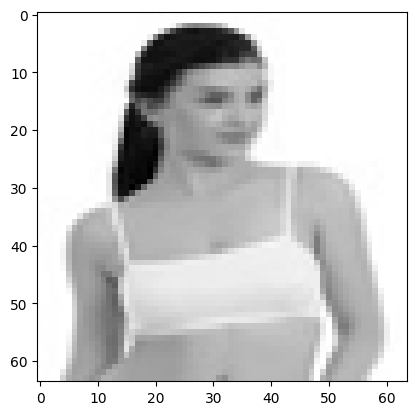

In [5]:
plt.imshow(train_dataset[0][0].reshape(64, 64), cmap='gray')#черно-белое изображение

In [6]:
pd.set_option('display.max_columns', 64)
pd.DataFrame(train_dataset[0][0].reshape(64, 64))#изображение в виде матрицы

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63
0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.992157,0.996078,1.000000,0.988235,0.996078,0.996078,0.992157,1.000000,1.000000,1.000000,0.992157,0.996078,0.996078,0.992157,1.000000,1.000000,0.996078,0.996078,0.996078,0.996078,0.992157,0.992157,0.996078,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.996078,0.996078,0.996078,0.996078,0.996078,0.996078,0.996078,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.992157,0.996078,1.000000,0.992157,1.000000,1.000000,0.992157,0.992157,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
2,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.996078,0.996078,0.996078,1.000000,1.000000,1.000000,0.960784,0.780392,0.627451,0.564706,0.537255,0.560784,0.588235,0.623529,0.698039,0.827451,0.980392,0.992157,1.000000,0.996078,0.992157,0.996078,0.996078,0.996078,0.996078,0.996078,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
3,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.996078,0.996078,1.000000,1.000000,0.882353,0.588235,0.313726,0.176471,0.137255,0.121569,0.109804,0.141176,0.141176,0.145098,0.176471,0.247059,0.360784,0.615686,0.905882,0.996078,0.996078,0.996078,0.992157,0.992157,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
4,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.996078,0.996078,1.000000,0.937255,0.541176,0.207843,0.109804,0.125490,0.141176,0.152941,0.149020,0.145098,0.152941,0.141176,0.145098,0.156863,0.152941,0.152941,0.149020,0.258824,0.611765,0.929412,1.000000,0.996078,0.992157,0.992157,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,0.996078,1.000000,0.992157,0.996078,1.000000,0.890196,0.709804,0.639216,0.650980,0.639216,0.600000,0.549020,0.482353,0.462745,0.596078,0.768627,0.643137,0.615686,0.627451,0.631373,0.627451,0.627451,0.627451,0.627451,0.639216,0.654902,0.678431,0.705882,0.698039,0.709804,0.729412,0.721569,0.717647,0.717647,0.721569,0.729412,0.733333,0.733333,0.729412,0.729412,0.729412,0.733333,0.733333,0.737255,0.737255,0.741176,0.729412,0.694118,0.894118,0.992157,0.882353,0.615686,0.627451,0.701961,0.717647,0.725490,0.729412,0.721569,0.745098,0.858824,1.000000,1.000000,1.0,1.000000
60,0.996078,0.996078,0.992157,0.996078,1.000000,0.839216,0.670588,0.639216,0.650980,0.639216,0.611765,0.552941,0.48627

C:\Users\maxsl\AppData\Local\Temp\ipykernel_8440\1587651808.py:9: DeprecationWarning: V1 Primitives are deprecated as of qiskit-machine-learning 0.8.0 and will be removed no sooner than 4 months after the release date. Use V2 primitives for continued compatibility and support.
  qnn = EstimatorQNN(


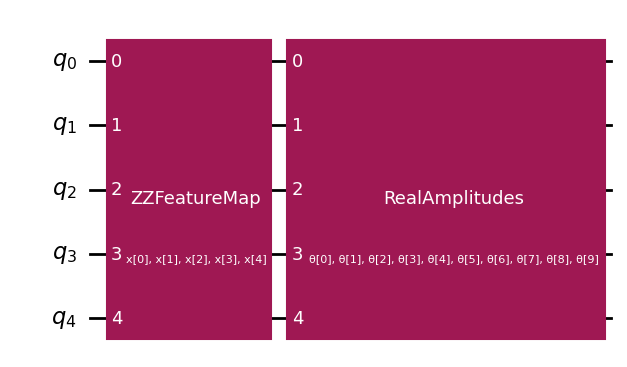

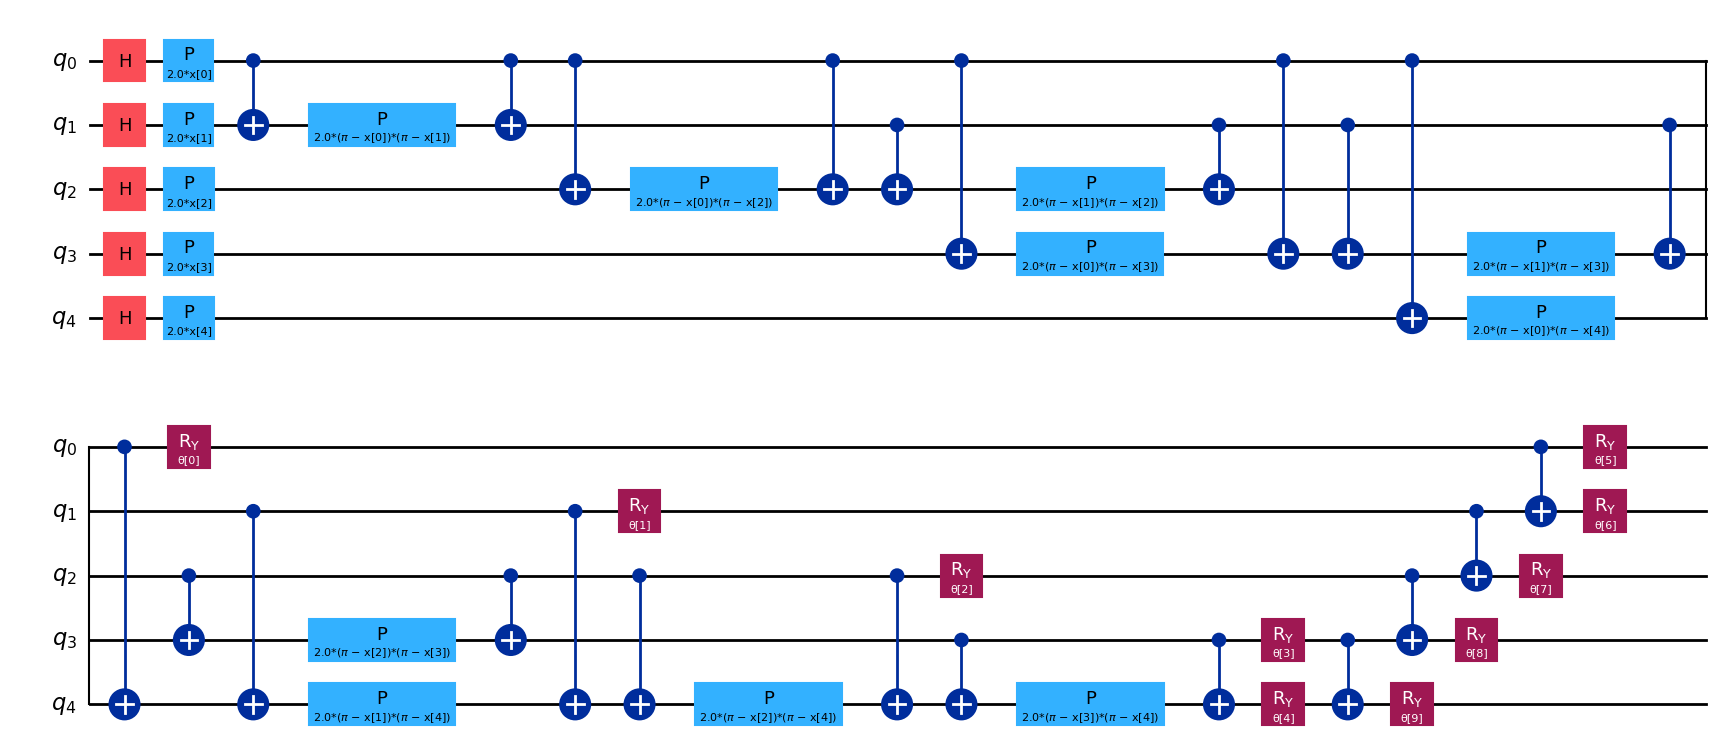

In [7]:
n_qubits = 5  

feature_map = ZZFeatureMap(feature_dimension=n_qubits, reps=1)
ansatz = RealAmplitudes(num_qubits=n_qubits, reps=1)

class QuantumLayer(nn.Module):
    def __init__(self):
        super().__init__()
        qnn = EstimatorQNN(
            circuit=feature_map.compose(ansatz),
            input_params=feature_map.parameters,
            weight_params=ansatz.parameters,
        )
        self.connector = TorchConnector(qnn)

    def forward(self, x):
        return self.connector(x)

quantum_layer = QuantumLayer()

# Визуализация квантовой схемы квантового слоя
%matplotlib inline
qc = feature_map.compose(ansatz)  
fig = qc.draw('mpl')
plt.show()

# Вывод квантовой схемы в базисе элементарных гейтов
qc_decomposed = feature_map.compose(ansatz).decompose()
qc_decomposed.draw('mpl')
plt.show()

In [8]:
class SimpleNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1)
        self.bn1 = nn.BatchNorm2d(16)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.bn2 = nn.BatchNorm2d(32)
        self.conv3 = nn.Conv2d(32, 1, kernel_size=3, stride=2, padding=1)
        self.bn3 = nn.BatchNorm2d(1)
        self.fc1 = nn.Linear(8 * 8, n_qubits)  
        self.quantum = quantum_layer
        self.classifier = nn.Linear(1, 10)

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.relu(self.bn3(self.conv3(x)))
        x = x.view(x.size(0), -1)  
        x = self.fc1(x)           
        x = self.quantum(x)        
        x = self.classifier(x)    
        return x

In [9]:
model = SimpleNN()
summary(model, (1, 64, 64), batch_size, device = device)
print(model)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [1200, 16, 32, 32]             160
       BatchNorm2d-2         [1200, 16, 32, 32]              32
              ReLU-3         [1200, 16, 32, 32]               0
            Conv2d-4         [1200, 32, 16, 16]           4,640
       BatchNorm2d-5         [1200, 32, 16, 16]              64
              ReLU-6         [1200, 32, 16, 16]               0
            Conv2d-7            [1200, 1, 8, 8]             289
       BatchNorm2d-8            [1200, 1, 8, 8]               2
              ReLU-9            [1200, 1, 8, 8]               0
           Linear-10                  [1200, 5]             325
   TorchConnector-11                  [1200, 1]              10
     QuantumLayer-12                  [1200, 1]               0
           Linear-13                 [1200, 10]              20
Total params: 5,542
Trainable params: 5

In [10]:
optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
loss_fn = nn.CrossEntropyLoss()

In [11]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.train()
    train_loss, correct = 0, 0
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device).float(), y.to(device)

        # Compute prediction error
        #print(X, data_prep(X))
        pred = model(X)
        loss = loss_fn(pred, y)

        train_loss += loss_fn(pred, y).item()
        correct += (pred.argmax(1) == y).type(torch.float).sum().item()

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    if batch % 100 == 0:
        loss, current = loss.item(), (batch + 1) * len(X)
        print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")
    
    train_loss /= num_batches
    correct /= size

    return correct, train_loss

def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device).float(), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

    return correct, test_loss

In [12]:
history = {
    'train_loss':[],
    'train_accuracy':[],
    'val_loss':[],
    'val_accuracy':[],
    'test_loss':[],
    'test_accuracy':[]
}

for t in range(epochs):
    running_loss = 0.0
    correct = 0
    total = 0
    print(f"Epoch {t+1}\n-------------------------------")
    #if(t % 2 == 0):
    #    initial_lr /= 2
    #    optimizer = torch.optim.Adam(model.parameters(), lr=initial_lr)
    acc, loss = train(train_dataloader, model, loss_fn, optimizer)
    history['train_accuracy'].append(acc)
    history['train_loss'].append(loss)
    acc, loss = test(test_dataloader, model, loss_fn)
    history['val_accuracy'].append(acc)
    history['val_loss'].append(loss)
print("Done!")

Epoch 1
-------------------------------


KeyboardInterrupt: 

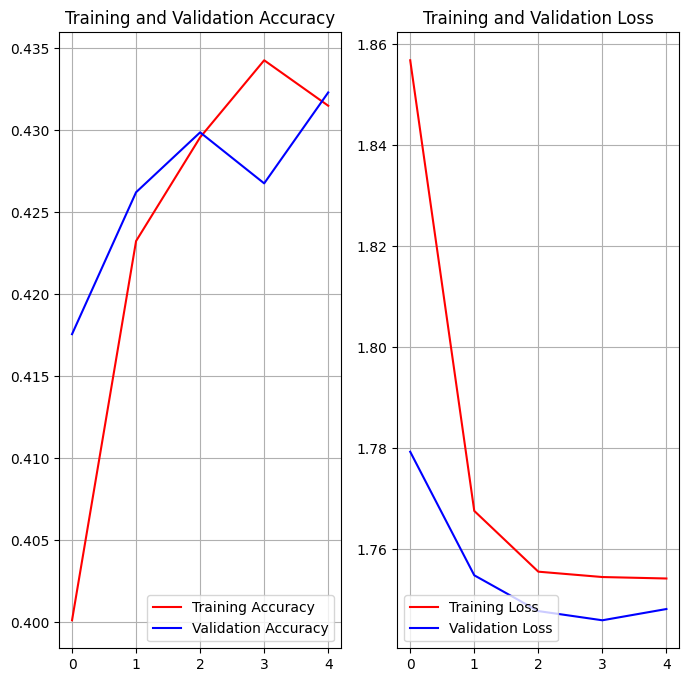

In [ ]:
epochs_range = range(epochs)
plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, history['train_accuracy'], label='Training Accuracy', color='red')
plt.plot(epochs_range, history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, history['train_loss'], label='Training Loss', color='red')
plt.plot(epochs_range, history['val_loss'], label='Validation Loss', color='blue')
plt.legend(loc='lower left')
plt.title('Training and Validation Loss')
plt.grid()
plt.show()

In [ ]:
model.eval()
test_dataloader
predictions = torch.LongTensor().to(device)
cmt = torch.zeros(10, 10, dtype=torch.int32)#Матрица ошибок
with torch.no_grad():
    for X, y in test_dataloader:
        X, y = X.to(device).float(), y.to(device)
        preds = model(X.to(device))
        predictions = preds.argmax(dim=1)
        cmt[y, predictions] += 1
    

In [ ]:
pd.set_option('display.max_columns', 10)
pd.DataFrame(cmt.reshape(10, 10))#строка истинное значение, столбец предсказанное

,0,1,2,3,4,5,6,7,8,9
0,2891,189,0,0,0,0,0,0,0,0
1,1164,305,0,0,0,0,0,0,0,0
2,542,69,0,0,0,0,0,0,0,0
3,443,95,0,0,0,0,0,0,0,0
4,396,112,0,0,0,0,0,0,0,0
5,322,40,0,0,0,0,0,0,0,0
6,169,47,0,0,0,0,0,0,0,0
7,178,37,0,0,0,0,0,0,0,0
8,175,27,0,0,0,0,0,0,0,0
9,136,56,0,0,0,0,0,0,0,0
